In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score, accuracy_score

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import roc_auc_score

In [4]:
url="https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv"
df = pd.read_csv(url)
df.head(5)           

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [5]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before imputation:
lead_source          148
industry             240
employment_status    194
location             208
annual_income        369
lead_score            35
dtype: int64


In [6]:
categorical = list(df.select_dtypes(include=['object', 'str']).columns)
numerical = [c for c in df.select_dtypes(include=['number']).columns if c != 'converted']

In [7]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [8]:
if 'converted' in df.columns:
    df['converted'] = df['converted'].fillna(0).astype(int)
print("\nRemaining missing values across entire dataset:", df.isnull().sum().sum())


Remaining missing values across entire dataset: 0


In [9]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [10]:
y_train = df_train['converted'].values

# 2. Features to evaluate
features = [
    'lead_score',
    'number_of_courses_viewed',
    'interaction_count',
    'annual_income'
]

# 3. Calculate ROC AUC on df_train (inverting if AUC < 0.5)
auc_scores = {}
for col in features:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    auc_scores[col] = auc

# 4. Display ranked results
auc_results = pd.Series(auc_scores).sort_values(ascending=False)
print("ROC AUC scores on training set:")
print(auc_results.to_string())
print("-" * 35)
print(f"Highest AUC: {auc_results.idxmax()} ({auc_results.max():.4f})")

ROC AUC scores on training set:
lead_score                  0.788225
interaction_count           0.764920
number_of_courses_viewed    0.722989
annual_income               0.608198
-----------------------------------
Highest AUC: lead_score (0.7882)


In [11]:
# 1. إعداد قائمة المتغيرات (Categorical + Numerical) بدون الهدف
features = [c for c in df.columns if c != 'converted']

# 2. ترميز الميزات عبر DictVectorizer
train_dicts = df_train[features].to_dict(orient='records')
val_dicts = df_val[features].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

# 3. تدريب النموذج بالمعاملات المحددة في السؤال
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# 4. التنبؤ بالاحتمالات وحساب AUC على مجموعة التحقق
y_val = df_val['converted'].values
y_pred_proba = model.predict_proba(X_val)[:, 1]

auc_val = roc_auc_score(y_val, y_pred_proba)
print(f"Validation AUC: {auc_val:.4f}")
print(f"Rounded (3 digits): {round(auc_val, 3)}")

Validation AUC: 0.7318
Rounded (3 digits): 0.732


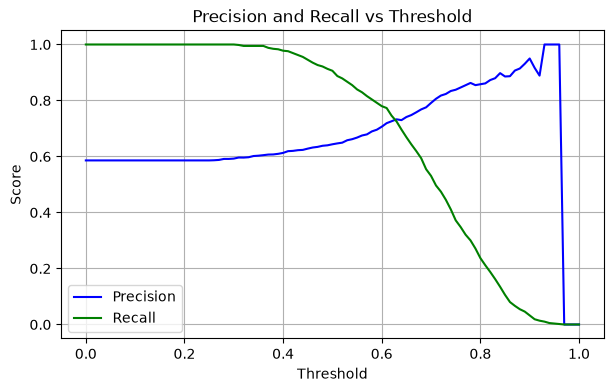

Intersection Threshold: 0.63

Absolute difference for question options:
Threshold 0.43 -> Precision: 0.623, Recall: 0.962, |P - R|: 0.3399
Threshold 0.63 -> Precision: 0.733, Recall: 0.725, |P - R|: 0.0075
Threshold 0.73 -> Precision: 0.823, Recall: 0.445, |P - R|: 0.3780
Threshold 0.83 -> Precision: 0.880, Recall: 0.162, |P - R|: 0.7175


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# 1. إعداد قائمة عتبات الاحتمال من 0.0 إلى 1.0 بخطوة 0.01
thresholds = np.linspace(0.0, 1.0, 101)

precisions = []
recalls = []

# y_pred_proba و y_val محسوبة ومجهزة من السؤال السابق
for t in thresholds:
    actual_pos = (y_val == 1)
    pred_pos = (y_pred_proba >= t)
    
    tp = (pred_pos & actual_pos).sum()
    fp = (pred_pos & ~actual_pos).sum()
    fn = (~pred_pos & actual_pos).sum()
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    precisions.append(p)
    recalls.append(r)

precisions = np.array(precisions)
recalls = np.array(recalls)

# 2. رسم المنحنيين لتوضيح نقطة التقاطع
plt.figure(figsize=(7, 4))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# 3. إيجاد العتبة التي يتقاطع عندها المنحنيان (أصغر فرق مطلق مع استبعاد الأصفار)
valid_mask = (precisions > 0) & (recalls > 0)
diff = np.abs(precisions[valid_mask] - recalls[valid_mask])
best_t = thresholds[valid_mask][np.argmin(diff)]

print(f"Intersection Threshold: {best_t:.2f}")

# فحص الفرق لكل خيار من خيارات السؤال
options = [0.43, 0.63, 0.73, 0.83]
print("\nAbsolute difference for question options:")
for opt in options:
    idx = int(round(opt * 100))
    p_val, r_val = precisions[idx], recalls[idx]
    print(f"Threshold {opt:.2f} -> Precision: {p_val:.3f}, Recall: {r_val:.3f}, |P - R|: {abs(p_val - r_val):.4f}")

In [13]:
import numpy as np
import pandas as pd

thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []

for t in thresholds:
    actual_pos = (y_val == 1)
    pred_pos = (y_pred_proba >= t)
    
    tp = (pred_pos & actual_pos).sum()
    fp = (pred_pos & ~actual_pos).sum()
    fn = (~pred_pos & actual_pos).sum()
    
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    f1_scores.append(f1)

f1_scores = np.array(f1_scores)

# إيجاد العتبة ذات أعلى قيمة F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Max F1 Score: {f1_scores[best_idx]:.4f} at threshold: {best_threshold:.2f}")

# مقارنة قيم F1 للخيارات الأربعة المطروحة في السؤال
options = [0.21, 0.41, 0.61, 0.81]
print("\nF1 scores for question options:")
for opt in options:
    idx = int(round(opt * 100))
    print(f"Threshold {opt:.2f} -> F1: {f1_scores[idx]:.4f}")

Max F1 Score: 0.7576 at threshold: 0.41

F1 scores for question options:
Threshold 0.21 -> F1: 0.7390
Threshold 0.41 -> F1: 0.7576
Threshold 0.61 -> F1: 0.7451
Threshold 0.81 -> F1: 0.3397


In [14]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# 1. إعداد قائمة الميزات بدون الهدف
features = [c for c in df.columns if c != 'converted']

# 2. ضبط KFold كما هو محدد في نص السؤال
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []

# 3. التكرار عبر الطيات الخمس
for train_idx, val_idx in kfold.split(df_full_train):
    df_train_fold = df_full_train.iloc[train_idx]
    df_val_fold = df_full_train.iloc[val_idx]
    
    y_train_fold = df_train_fold['converted'].values
    y_val_fold = df_val_fold['converted'].values
    
    # One-hot encoding باستخدام DictVectorizer داخل كل Fold
    train_dicts = df_train_fold[features].to_dict(orient='records')
    val_dicts = df_val_fold[features].to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    X_train_fold = dv.fit_transform(train_dicts)
    X_val_fold = dv.transform(val_dicts)
    
    # تدريب النموذج بالمعاملات المحددة
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)
    
    # حساب AUC على مجموعة التحقق الخاصة بالطية
    y_pred = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_pred)
    auc_scores.append(auc)

# 4. حساب الانحراف المعياري
scores_std = np.std(auc_scores)
print("AUC scores across folds:", [round(s, 4) for s in auc_scores])
print(f"Mean AUC: {np.mean(auc_scores):.4f}")
print(f"Standard Deviation (exact): {scores_std:.4f}")
print(f"Standard Deviation (rounded to 3 digits): {round(scores_std, 3)}")

AUC scores across folds: [0.7306, 0.7296, 0.7363, 0.7412, 0.7209]
Mean AUC: 0.7317
Standard Deviation (exact): 0.0069
Standard Deviation (rounded to 3 digits): 0.007


In [15]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Features list (excluding target 'converted')
features = [c for c in df.columns if c != 'converted']

# Candidate C values specified in the prompt
c_values = [0.000001, 0.001, 1]

# KFold with the exact configuration from Q5
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

results = []

for C in c_values:
    scores = []
    
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train_fold = df_full_train.iloc[train_idx]
        df_val_fold = df_full_train.iloc[val_idx]
        
        y_train_fold = df_train_fold['converted'].values
        y_val_fold = df_val_fold['converted'].values
        
        train_dicts = df_train_fold[features].to_dict(orient='records')
        val_dicts = df_val_fold[features].to_dict(orient='records')
        
        dv = DictVectorizer(sparse=False)
        X_train_fold = dv.fit_transform(train_dicts)
        X_val_fold = dv.transform(val_dicts)
        
        model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model.fit(X_train_fold, y_train_fold)
        
        y_pred = model.predict_proba(X_val_fold)[:, 1]
        auc = roc_auc_score(y_val_fold, y_pred)
        scores.append(auc)
        
    mean_auc = round(np.mean(scores), 3)
    std_auc = round(np.std(scores), 3)
    results.append({'C': C, 'mean_auc': mean_auc, 'std': std_auc, 'raw_mean': np.mean(scores)})
    print(f"C={C:<8} | Mean ROC AUC: {mean_auc:.3f} | Std: {std_auc:.3f} (raw mean: {np.mean(scores):.4f})")

C=1e-06    | Mean ROC AUC: 0.617 | Std: 0.019 (raw mean: 0.6167)
C=0.001    | Mean ROC AUC: 0.749 | Std: 0.010 (raw mean: 0.7492)
C=1        | Mean ROC AUC: 0.732 | Std: 0.007 (raw mean: 0.7317)
